# RANSAC Empirical Analysis
**CS5008 Final Project — Arsh Singh**

This notebook generates plots for the report based on the data generated by the experiments.


## TABLE OF CONTENT

- [Setup](#setup)
- [Experiment 1 — Time vs k](#experiment-01)
- [Experiment 2 — Time vs epsilon](#experiment-02)
- [Experiment 3 — Time vs threshold](#experiment-03)
- [Experiment 4 — Outlier Fraction](#experiment-1)
- [Experiment 5 — Structural Bias](#experiment-2)
- [Experiment 6 — Model Degree](#experiment-3)


---
## 1. Setup and Imports <a id="setup"></a>

In [1]:
import sys
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# plot style
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

# output directory for saved figures
import os
FIG_DIR = '../figures'
os.makedirs(FIG_DIR, exist_ok=True)
DATA_DIR = 'results'
os.makedirs(DATA_DIR, exist_ok=True)

# Column rename dictionary shared across all three experiments.
# Apply with: df.rename(columns=COL_NAMES, inplace=True)

COL_NAMES = {
    'index':       'Run Index',
    'n':           'Total Points (N)',
    'epsilon':     'Outlier Fraction (ε)',
    'd':           'Expected Inliers (d)',
    'm':           'Model Parameters (m)',
    'k':           'Iterations Used (k)',
    'k_budget':    'Iteration Budget (k)',
    'k_theory':    'Iterations Required by Theory',
    't':           'Inlier Threshold (t)',
    'pr':          'Bias Probability (pr)',
    'bias_type':   'Bias Type',
    'repeat':      'Repeat Number',
    'time_mu_s':   'Wall-Clock Time (μs)',
    'model_error': 'Model Error (Euclidean)',
}
print('Setup complete.')

Setup complete.


---
## Experiment 1: Does wall-clock time grow linearly with k? <a id="experiment-01"></a>
 *     Fixes epsilon = 0.5. Varies k from 10 to 500 in steps of 10.
 *     Runs for linear (m = 2) and quadratic (m = 3) models.
 *     N_TOTAL = 1000 is fixed throughout.
 *     Repeats N_REPEATS times per condition.

In [2]:
df01 = pd.read_csv(f"{DATA_DIR}/exp1.csv")
df01.rename(columns=COL_NAMES, inplace=True)
df01.head()

,Run Index,Total Points (N),Outlier Fraction (ε),Expected Inliers (d),Model Parameters (m),Iterations Used (k),Inlier Threshold (t),Repeat Number,Wall-Clock Time (μs),Model Error (Euclidean)
0,0,1000,0.5,500,2,10,0.9957,0,229.0,5.273668
1,1,1000,0.5,500,2,10,1.0425,1,224.0,0.307783
2,2,1000,0.5,500,2,10,0.9425,2,231.0,0.126046
3,3,1000,0.5,500,2,10,0.9673,3,208.0,0.747024
4,4,1000,0.5,500,2,10,0.9838,4,215.0,0.504295


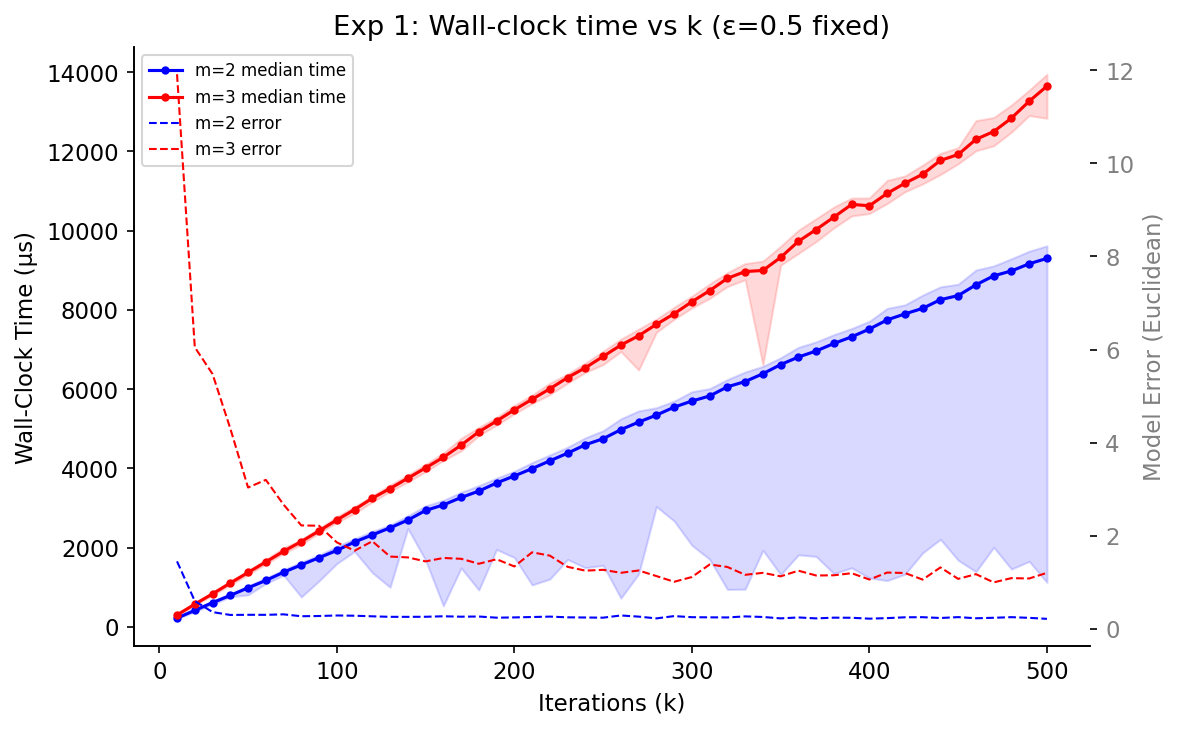

In [3]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

for m, color in [(2, "blue"), (3, "red")]:
    sub = df01[df01["Model Parameters (m)"] == m]
    grp = sub.groupby("Iterations Used (k)")["Wall-Clock Time (μs)"]
    means = grp.median()  # variable is called mean, but stores median. More approporiate vital stat
    lower = grp.quantile(0.10)
    upper = grp.quantile(0.90)

    ax1.plot(means.index, means.values,
             color=color, marker="o", markersize=3, label=f"m={m} median time")
    ax1.fill_between(means.index, lower, upper, alpha=0.15, color=color)

    grp2 = sub.groupby("Iterations Used (k)")["Model Error (Euclidean)"]
    ax2.plot(grp2.mean().index, grp2.mean().values,
             color=color, linestyle="--", linewidth=1, label=f"m={m} error")

ax1.set_xlabel("Iterations (k)")
ax1.set_ylabel("Wall-Clock Time (μs)")
ax2.set_ylabel("Model Error (Euclidean)", color="grey")
ax2.tick_params(axis="y", labelcolor="grey")
ax1.set_title("Exp 1: Wall-clock time vs k (ε=0.5 fixed)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exp1.png", dpi=150)
plt.show()

---

## Experiment 2: Does wall-clock time grow with epsilon for fixed k? <a id="experiment-02"></a>
 * Noiseless data.
 * Fixes k at the value computed for epsilon = 0.5.
 * Varies epsilon from 0.05 to 0.95 in steps of 0.05.
 * Runs for linear (m = 2) and
 * quadratic (m = 3) models.
 * N_TOTAL = 1000 is fixed throughout.
 * Repeats 100 times per condition.

In [4]:
df02 = pd.read_csv(f"{DATA_DIR}/exp2.csv")
df02.rename(columns=COL_NAMES, inplace=True)
df02.head()

,Run Index,Total Points (N),Outlier Fraction (ε),Expected Inliers (d),Model Parameters (m),Iterations Used (k),Inlier Threshold (t),Repeat Number,Wall-Clock Time (μs),Model Error (Euclidean)
0,0,1000,0.05,950,2,17,0.0001,0,42.0,0.0
1,1,1000,0.05,950,2,17,0.0001,1,41.0,0.0
2,2,1000,0.05,950,2,17,0.0001,2,42.0,0.0
3,3,1000,0.05,950,2,17,0.0001,3,54.0,0.0
4,4,1000,0.05,950,2,17,0.0001,4,53.0,0.0


In [5]:
df02.groupby('Outlier Fraction (ε)')['Expected Inliers (d)'].first().reset_index()

,Outlier Fraction (ε),Expected Inliers (d)
0,0.05,950
1,0.10,900
2,0.15,850
3,0.20,800
4,0.25,750
5,0.30,700
6,0.35,650
7,0.40,600
8,0.45,550
9,0.50,500


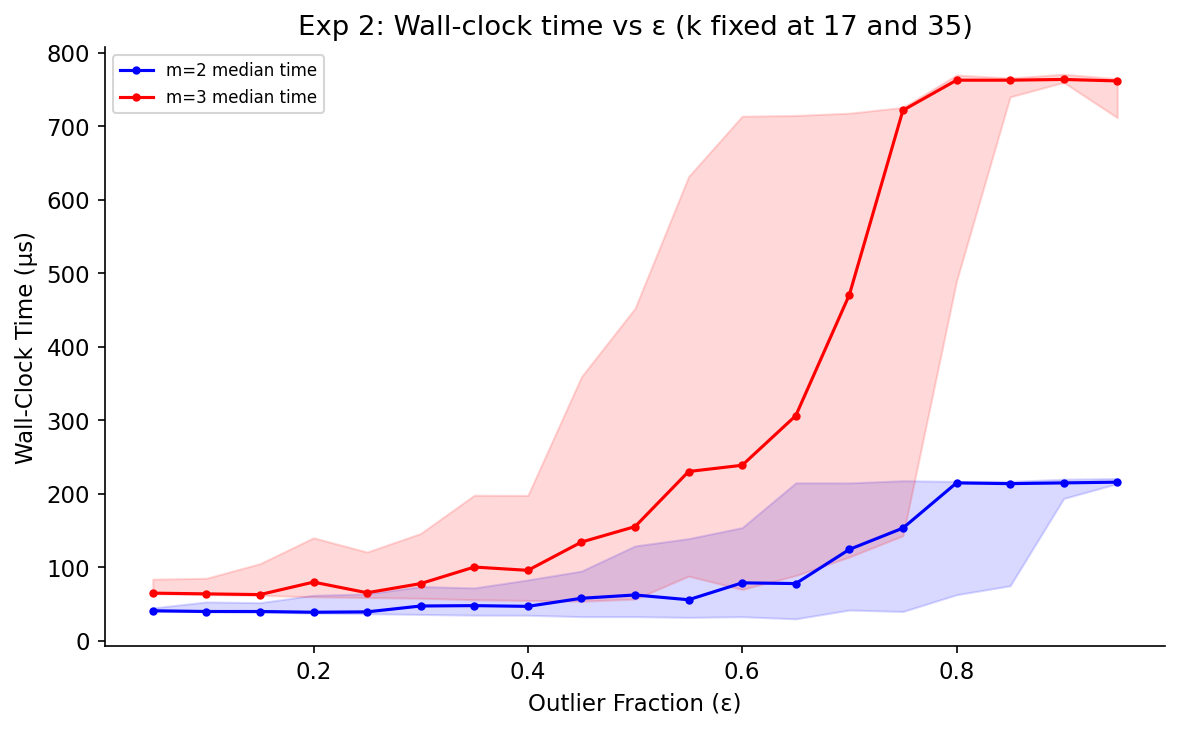

In [6]:
fig, ax1 = plt.subplots(figsize=(8, 5))

for m, color in [(2, "blue"), (3, "red")]:
    sub = df02[df02["Model Parameters (m)"] == m]
    grp = sub.groupby("Outlier Fraction (ε)")["Wall-Clock Time (μs)"]
    means = grp.median()  # variable is called mean, but stores median. More approporiate vital stat
    lower = grp.quantile(0.10)
    upper = grp.quantile(0.90)
    
    ax1.plot(means.index, means.values,
             color=color, marker="o", markersize=3, label=f"m={m} median time")
    ax1.fill_between(means.index, lower, upper, alpha=0.15, color=color)

    grp2 = sub.groupby("Outlier Fraction (ε)")["Model Error (Euclidean)"]

k_2 = df02["Iterations Used (k)"].min()
k_3 = df02["Iterations Used (k)"].max()
ax1.set_xlabel("Outlier Fraction (ε)")
ax1.set_ylabel("Wall-Clock Time (μs)")
title = f"Exp 2: Wall-clock time vs ε (k fixed at {k_2} and {k_3})"
ax1.set_title(title)

lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exp2.png", dpi=150)
plt.show()

### Observations
* Early stopping kicks in after eps = 0.5

---

## Experiment 3: Does wall-clock time vary with inlier threshold t? <a id="experiment-03"></a>
 *     Fixes k at the value computed for epsilon = 0.5 and fixes
 *     epsilon = 0.5. Varies t as a multiplier of noise_std from 0.5
 *     to 5.0 in steps of 0.5. Runs for linear (m = 2) and quadratic
 *     (m = 3) models. N_TOTAL = 1000 is fixed throughout.
 *     Repeats N_REPEATS times per condition.

In [7]:
df03 = pd.read_csv(f"{DATA_DIR}/exp3.csv")
df03.rename(columns=COL_NAMES, inplace=True)
df03.head()

,Run Index,Total Points (N),Outlier Fraction (ε),Expected Inliers (d),Model Parameters (m),Iterations Used (k),Inlier Threshold (t),t_multiplier,Repeat Number,Wall-Clock Time (μs),Model Error (Euclidean)
0,0,1000,0.5,500,2,17,0.25,0.5,0,268.0,0.776784
1,1,1000,0.5,500,2,17,0.25,0.5,1,281.0,1.194283
2,2,1000,0.5,500,2,17,0.25,0.5,2,281.0,3.126619
3,3,1000,0.5,500,2,17,0.25,0.5,3,300.0,0.181277
4,4,1000,0.5,500,2,17,0.25,0.5,4,293.0,1.313402


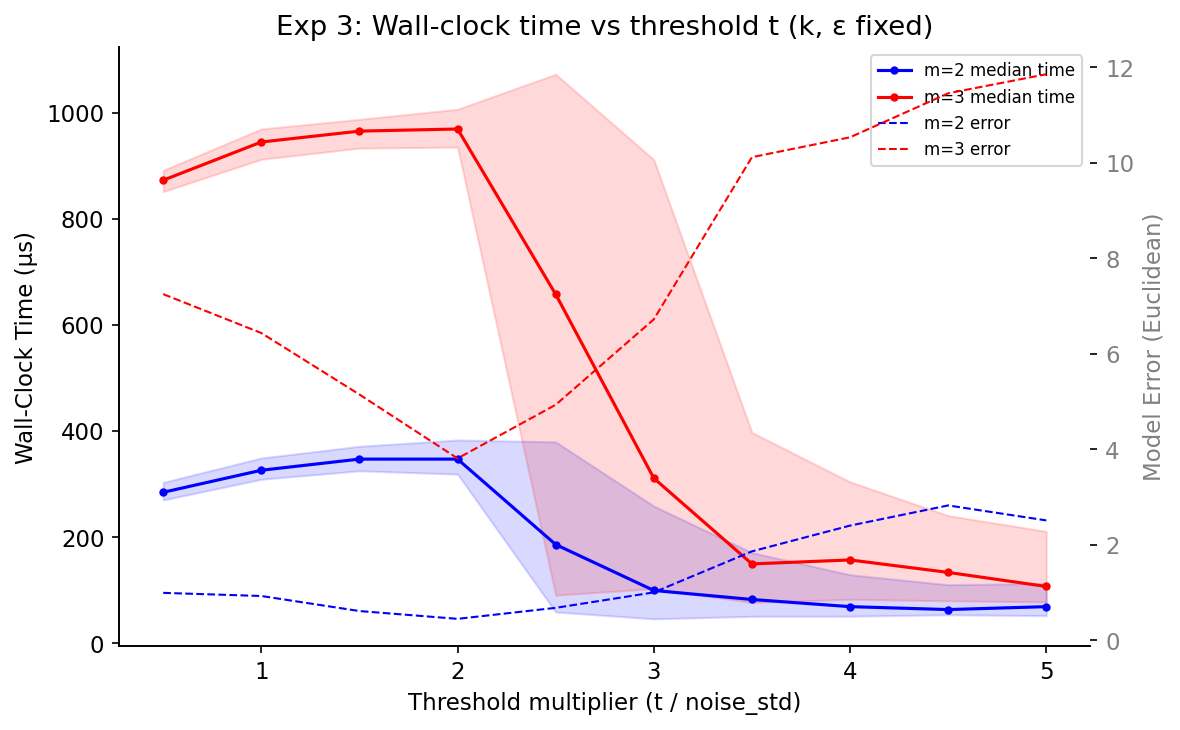

In [8]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

for m, color in [(2, "blue"), (3, "red")]:
    sub = df03[df03["Model Parameters (m)"] == m]
    grp = sub.groupby("t_multiplier")["Wall-Clock Time (μs)"]
    means = grp.median()  # variable is called mean, but stores median. More approporiate vital stat
    lower = grp.quantile(0.10)
    upper = grp.quantile(0.90)

    ax1.plot(means.index, means.values,
             color=color, marker="o", markersize=3, label=f"m={m} median time")
    ax1.fill_between(means.index, lower, upper, alpha=0.15, color=color)

    grp2 = sub.groupby("t_multiplier")["Model Error (Euclidean)"]
    ax2.plot(grp2.mean().index, grp2.mean().values,
             color=color, linestyle="--", linewidth=1, label=f"m={m} error")

ax1.set_xlabel("Threshold multiplier (t / noise_std)")
ax1.set_ylabel("Wall-Clock Time (μs)")
ax2.set_ylabel("Model Error (Euclidean)", color="grey")
ax2.tick_params(axis="y", labelcolor="grey")
ax1.set_title("Exp 3: Wall-clock time vs threshold t (k, ε fixed)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exp3.png", dpi=150)
plt.show()

### Observation: 
* Since we have kept noise at 2, for small t up to 2, even true inliers may fall outside the threshold due to noise — so RANSAC struggles to find d inliers and runs many iterations before succeeding or exhausting k. That's the slow region.
* Beyond multiplier 2, the threshold is so wide that outliers start counting as inliers too, inflating the consensus set size past d quickly and triggering early stopping — hence the drop.

---

## Experiment 4: How does RANSAC break down as outlier fraction increases? <a id="experiment-1"></a>
 *     Fixes k at the value computed for epsilon = 0.5 and varies epsilon
 *     from 0.1 to 0.9 in steps of 0.1. Runs for linear (m = 2) and
 *     quadratic (m = 3) models. N_TOTAL = 1000 is fixed throughout.
 *     Repeats N_REPEATS times per condition.

In [9]:
df4 = pd.read_csv('results/exp4.csv').rename(columns=COL_NAMES)
df4.head()

,Run Index,Total Points (N),Outlier Fraction (ε),Expected Inliers (d),Model Parameters (m),Iterations Used (k),Inlier Threshold (t),Repeat Number,Wall-Clock Time (μs),Model Error (Euclidean)
0,0,1000,0.05,950,2,17,0.9933,0,361.0,0.157594
1,1,1000,0.05,950,2,17,1.0490,1,386.0,0.083433
2,2,1000,0.05,950,2,17,0.9894,2,372.0,0.077497
3,3,1000,0.05,950,2,17,1.0039,3,390.0,0.202383
4,4,1000,0.05,950,2,17,0.9802,4,390.0,0.133550


In [10]:
agg4 = (df4.groupby(['Model Parameters (m)', 'Outlier Fraction (ε)'])
           ['Model Error (Euclidean)']
           .agg(mean_error='mean', std_error='std', count='count')
           .reset_index())

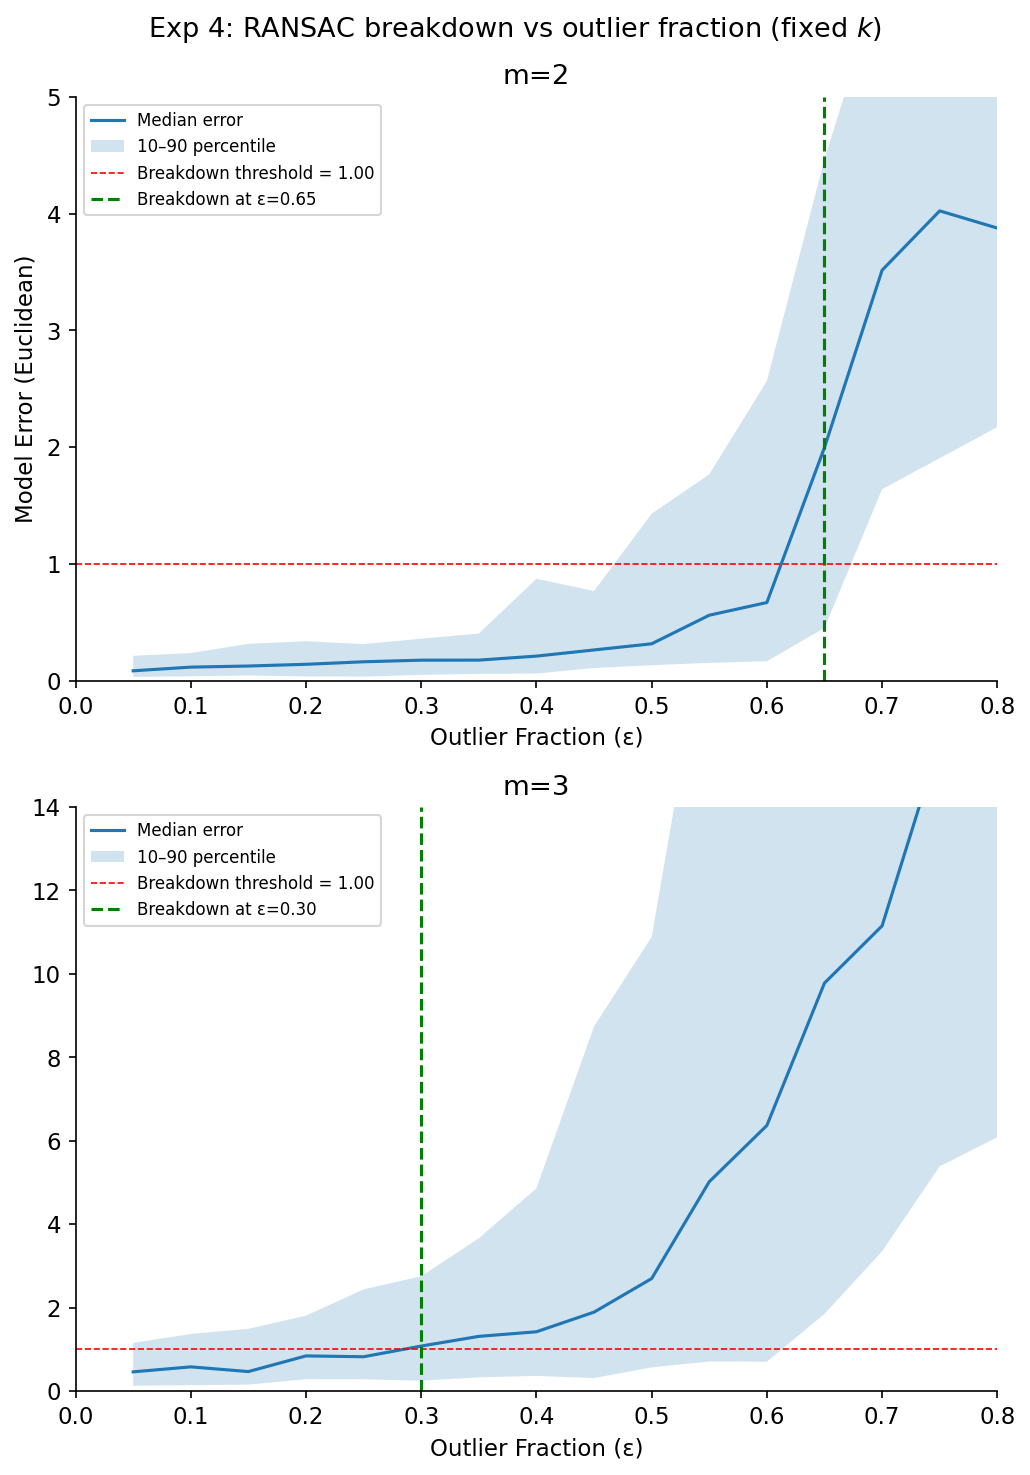

In [11]:
BREAKDOWN_THRESHOLD = 2 * 0.5  # 2 * NOISE_STD

models = df4["Model Parameters (m)"].unique()
fig, axes = plt.subplots(len(models), 1, figsize=(7, 10))

for i, m in enumerate(models):
    ax = axes[i]
    sub = df4[df4["Model Parameters (m)"] == m]
    grp = sub.groupby("Outlier Fraction (ε)")["Model Error (Euclidean)"]

    means = grp.median()  # variable is called mean, but stores median. More approporiate vital stat
    lower = grp.quantile(0.10)
    upper = grp.quantile(0.90)
    breakdown_rows = means[means > BREAKDOWN_THRESHOLD]
    breakdown_eps = breakdown_rows.index[0] if not breakdown_rows.empty else None
    
    ax.plot(means.index, means.values, label="Median error")
    ax.fill_between(means.index, lower, upper, alpha=0.2, label="10–90 percentile")
    ax.axhline(BREAKDOWN_THRESHOLD, color="red", linestyle="--",
               linewidth=0.8, label=f"Breakdown threshold = {BREAKDOWN_THRESHOLD:.2f}")

    if breakdown_eps is not None:
        ax.axvline(x=breakdown_eps, color="green", linestyle="--",
                   label=f"Breakdown at ε={breakdown_eps:.2f}")

    ax.set_title(f"m={m}")
    ax.set_xlabel("Outlier Fraction (ε)")
    ax.set_xlim(0, 0.8)
    if i == 0:
        ax.set_ylim(0, 5)
    else:
        ax.set_ylim(0, 14)
    if i == 0:
        ax.set_ylabel("Model Error (Euclidean)")
    ax.legend(fontsize=8)
    
    
plt.suptitle("Exp 4: RANSAC breakdown vs outlier fraction (fixed $k$)",
             fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exp4.png", dpi=150)
plt.show()


--- 

## Experiment 5: At what structural bias probability does RANSAC fail? <a id="experiment-2"></a>
 * Fixes epsilon = 0.1
 * varies pr from 0.0 to 1.0 in steps of 0.05.
 * Runs for three bias types: constant, linear, periodic.
 * Runs for linear (m = 2) and quadratic (m = 3) models.
 * N_TOTAL = 1000 is fixed throughout.
 * Repeats 100 times per condition.

In [28]:
df5 = pd.read_csv('results/exp5.csv').rename(columns=COL_NAMES)
df5.head()

,Run Index,Total Points (N),Outlier Fraction (ε),Expected Inliers (d),Model Parameters (m),Iterations Used (k),Inlier Threshold (t),Bias Probability (pr),Bias Type,Repeat Number,Wall-Clock Time (μs),Model Error (Euclidean)
0,0,1000,0.1,900,2,170,1.0117,0.0,constant,0,3240.0,0.097508
1,1,1000,0.1,900,2,170,0.9834,0.0,constant,1,3162.0,0.067110
2,2,1000,0.1,900,2,170,1.0055,0.0,constant,2,3219.0,0.024484
3,3,1000,0.1,900,2,170,0.9879,0.0,constant,3,3289.0,0.040451
4,4,1000,0.1,900,2,170,1.0336,0.0,constant,4,3231.0,0.099203


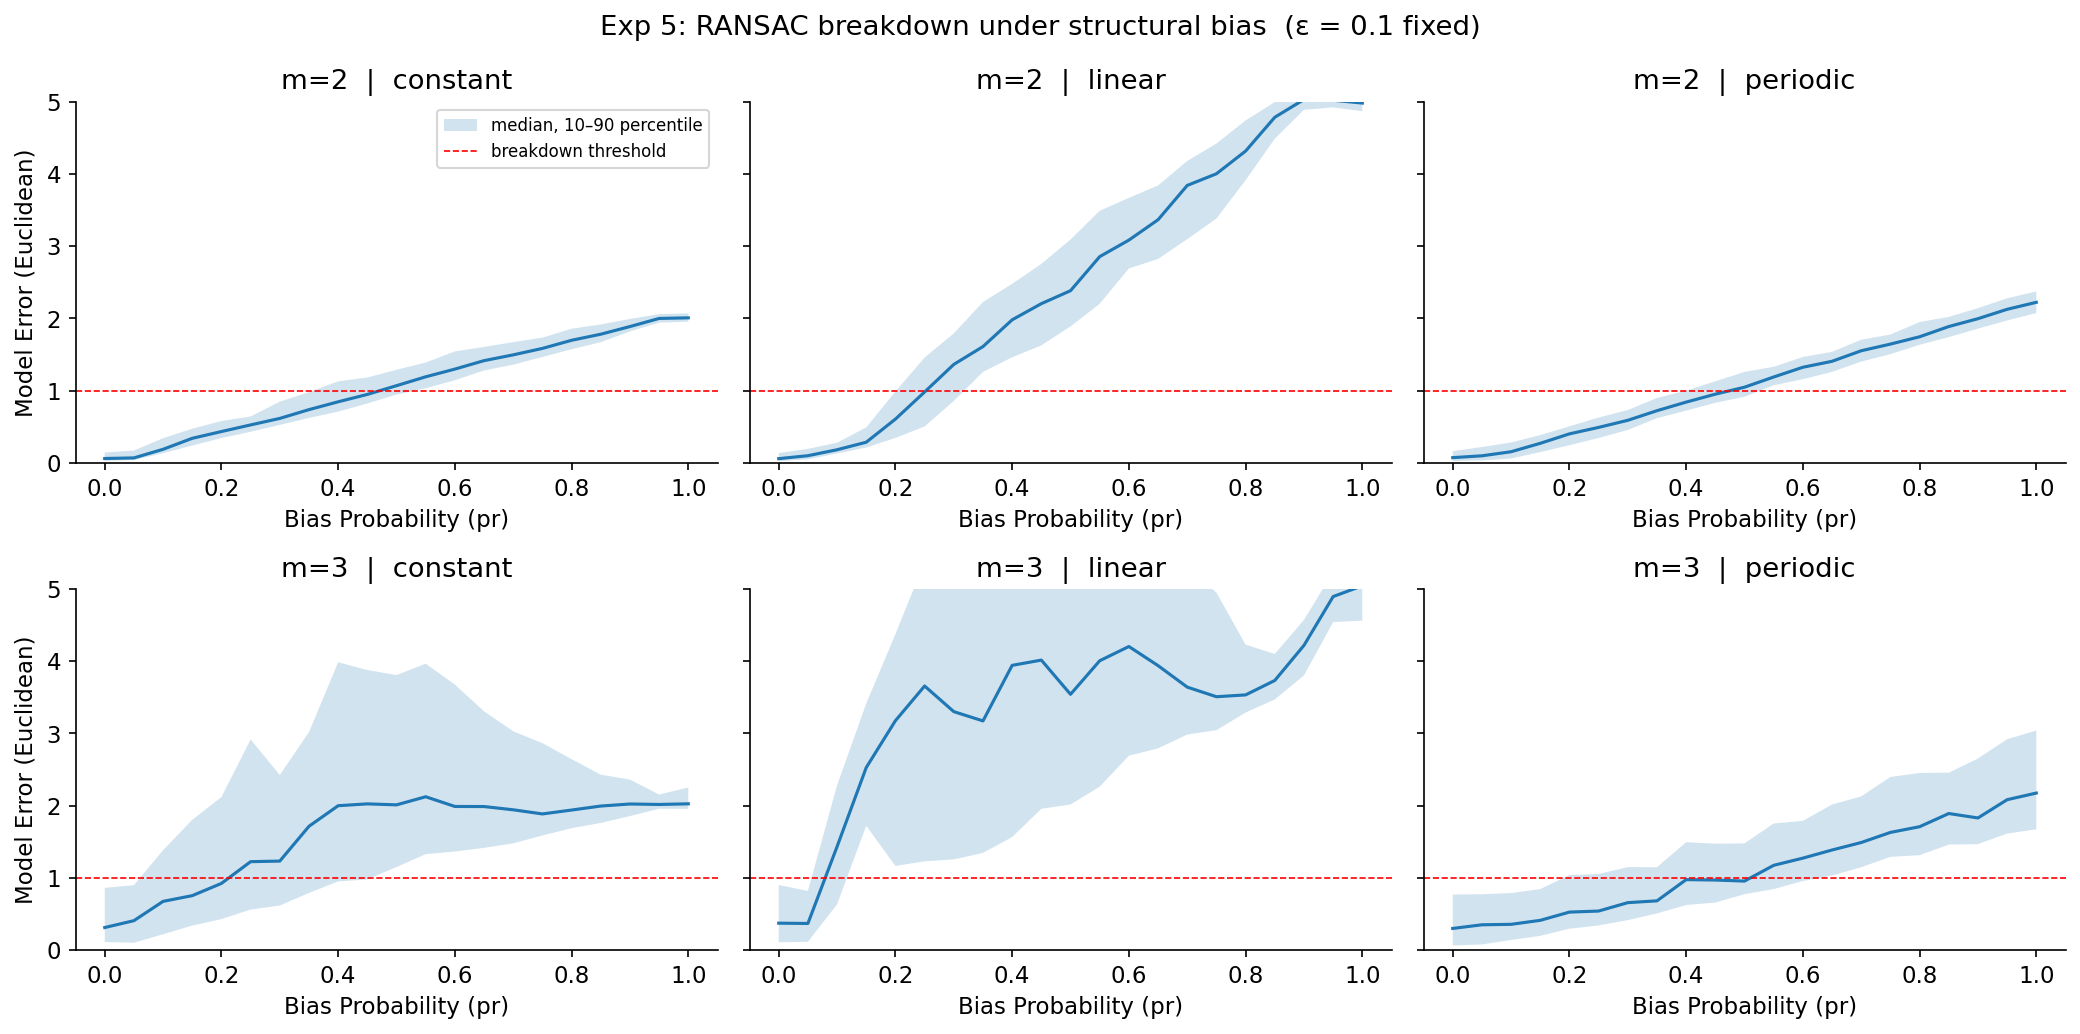

In [29]:
BREAKDOWN_THRESHOLD = 2 * 0.5  # 2 * NOISE_STD

bias_types = df5["Bias Type"].unique()
models     = df5["Model Parameters (m)"].unique()

fig, axes = plt.subplots(len(models), len(bias_types),
                         figsize=(14, 7), sharey=True)

for i, m in enumerate(models):
    for j, bias in enumerate(bias_types):
        ax  = axes[i, j]
        sub = df5[(df5["Model Parameters (m)"] == m) &
                  (df5["Bias Type"] == bias)]
        grp = sub.groupby("Bias Probability (pr)")["Model Error (Euclidean)"]

        means = grp.median()  # variable is called mean, but stores median. More approporiate vital stat
        lower = grp.quantile(0.10)
        upper = grp.quantile(0.90)

        ax.plot(means.index, means.values)
        ax.fill_between(means.index, lower, upper, alpha=0.2, label='median, 10–90 percentile')
        ax.axhline(BREAKDOWN_THRESHOLD, color='red', linestyle='--',
                   linewidth=0.8, label='breakdown threshold')

        ax.set_title(f"m={m}  |  {bias}")
        ax.set_xlabel("Bias Probability (pr)")
        ax.set_ylim(0, 5)
        if j == 0:
            ax.set_ylabel("Model Error (Euclidean)")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)

plt.suptitle("Exp 5: RANSAC breakdown under structural bias  (ε = 0.1 fixed)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exp5.png", dpi=150)
plt.show()

### Observations:

Linear Model:
1. In presense of constant bias, RANSAC does not break down at any pr.
2. In presense of linear bias, RANSAC can recover true model at modest bias with all pr.
3. In presence of periodic bias again, RANSAC breaksdown at mediocre amounts of bias at pr ~0.5.

Quadratic Model:
1. In presense of constant bias the breakdown happens at pr = 0.3
2. With linear bias, there is no break-down.
3. In presence of periodic bias, RANSAC breaks down after modest amount of bias at pr ~0.4.

---
## Experiment 6 — At What Model Degree Does RANSAC Fail for a Budgeted or Fixed Iteration Count? <a id="experiment-3"></a>

Fix $\varepsilon = 0.15$. Vary $m$ from 2 to 5 in steps of 1. Run twice for $k$ = 800 and $k$ = 8000. `N` is 1000. Repeat 100 times.


In [14]:
df6 = pd.read_csv('results/exp6.csv').rename(columns=COL_NAMES)
df6.head()

,Run Index,Total Points (N),Outlier Fraction (ε),Expected Inliers (d),Model Parameters (m),Iteration Budget (k),Iterations Required by Theory,Inlier Threshold (t),Repeat Number,Wall-Clock Time (μs),Model Error (Euclidean)
0,0,1000,0.15,850,3,800,5,1.0,0,21099.0,0.121048
1,1,1000,0.15,850,3,800,5,1.0,1,21099.0,0.254198
2,2,1000,0.15,850,3,800,5,1.0,2,20962.0,0.950159
3,3,1000,0.15,850,3,800,5,1.0,3,21257.0,0.373842
4,4,1000,0.15,850,3,800,5,1.0,4,21007.0,0.584649


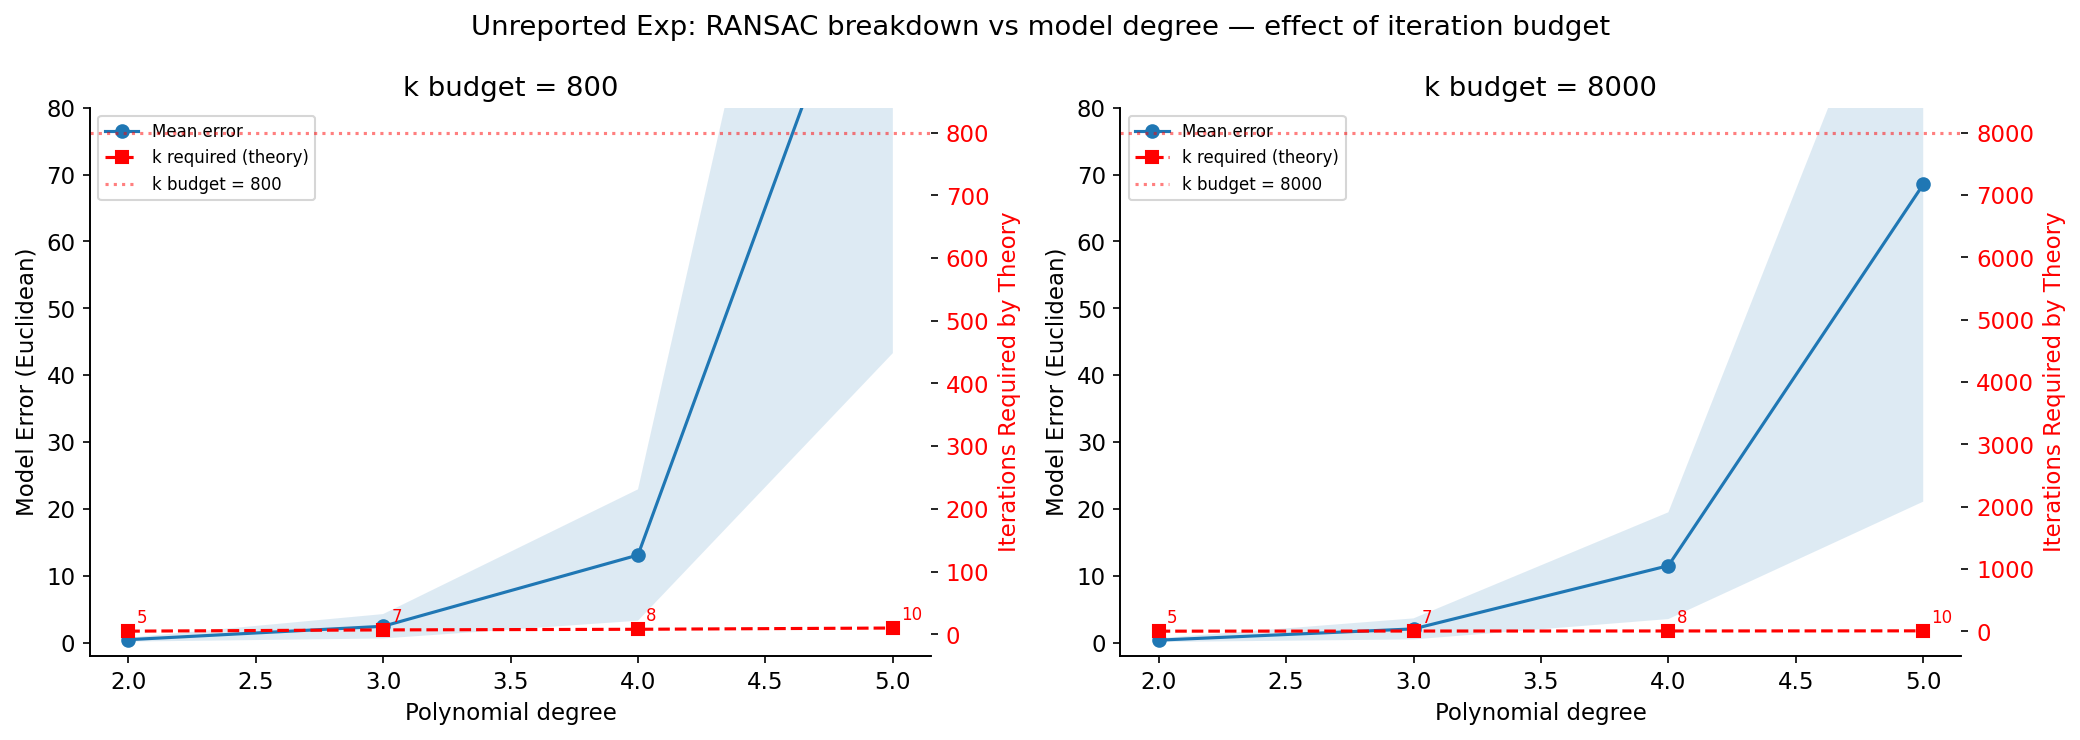

In [15]:
# Not fixed, uses mean, not used in report

df6["degree"] = df6["Model Parameters (m)"] - 1
sub100  = df6[df6["Iteration Budget (k)"].astype(int) == 800]
sub1000 = df6[df6["Iteration Budget (k)"].astype(int) == 8000]

agg100  = (sub100.groupby("degree")["Model Error (Euclidean)"]
                  .agg(mean_error="mean", std_error="std")
                  .reset_index())
agg1000 = (sub1000.groupby("degree")["Model Error (Euclidean)"]
                   .agg(mean_error="mean", std_error="std")
                   .reset_index())

agg_theory = (sub100.groupby("degree")["Iterations Required by Theory"]
                     .first().reset_index())
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 5))
# fig, (ax_l, ax_r) = plt.subplots(2, 1, figsize=(7, 10))

for ax1, agg, k_budget in [(ax_l, agg100, 800), (ax_r, agg1000, 8000)]:
    ax2 = ax1.twinx()

    ax1.plot(agg["degree"], agg["mean_error"],
             marker="o", label="Mean error")
    ax1.fill_between(agg["degree"],
                     agg["mean_error"] - agg["std_error"],
                     agg["mean_error"] + agg["std_error"],
                     alpha=0.15)

    ax2.plot(agg_theory["degree"],
             agg_theory["Iterations Required by Theory"],
             marker="s", color="red", linestyle="--",
             label="k required (theory)")
    for _, row in agg_theory.iterrows():
        ax2.annotate(f"{int(row['Iterations Required by Theory'])}",
                     xy=(row["degree"], row["Iterations Required by Theory"]),
                     xytext=(4, 4), textcoords="offset points",
                     color="red", fontsize=8)
    ax2.axhline(k_budget, color="red", linestyle=":",
                alpha=0.5, label=f"k budget = {k_budget}")
    ax2.tick_params(axis='y', labelcolor='red')
    ax1.set_xlabel("Polynomial degree")
    ax1.set_ylabel("Model Error (Euclidean)")
    ax2.set_ylabel("Iterations Required by Theory", color="red")
    ax1.set_title(f"k budget = {k_budget}")
    ax1.set_ylim(-2, 80)
    # if k_budget == 100:
    #     ax1.set_xlim(2, 5)
    # else:
    #     ax1.set_xlim(2, 8)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               loc="upper left", fontsize=8)

plt.suptitle("Unreported Exp: RANSAC breakdown vs model degree — effect of iteration budget")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exp6.png", dpi=150)
plt.show()


### Observations
* At m = 4 the model error is ~15 model errors  for k budget of 100x and ~ 1000x required for model errors. This breakdown is not due to $k$. Something else is going on. 

## Motivating Example
 * I create two overlapping graphs with the same true linear model.
 * I recover the underlying models in two ways:
    1. using fit_model over the appended dataset which is like solving
       naive OLS, and
    2. using stitch_models which is the RANSAC approach
 * Later I will plot this data and the models recovered using naive OLS and
 * the RANSAC parameters to visually compare the two approaches and
 * demonstrate the goodness of fit.

Output on Terminal:
```
as@Arshs-MacBook-Pro empirical_analysis % make example
gcc -Wall -std=c11 -o example.out motivating_example.c experiments.c ../src/model.c ../src/generator.c ../src/ransac.c -lm
./example.out
True params:  a0=5.0000  a1=2.0000

OLS graph 1:  a0=5.4119  a1=1.4164  error=0.7143
OLS graph 2:  a0=5.4076  a1=1.7971  error=0.4554
OLS combined:  a0=5.3181  a1=1.8685  error=0.3443

RANSAC graph 1: a0=5.0017  a1=2.0796  error=0.0796
RANSAC graph 2:  a0=5.0919  a1=1.9040  error=0.1329
RANSAC stitched:  a0=5.0328  a1=1.9863  error=0.0355
```

In [16]:
true_params     = [5.0000, 2.0000]

ols1_params     = [5.4119, 1.4164]
ols2_params     = [5.3181, 1.7971]
ols_comb_params = [5.5381, 1.8685]

ransac1_params  = [5.0017, 2.0796]
ransac2_params  = [5.0919, 1.9040]
stitch_params   = [5.0328, 1.9863]

In [17]:
df_ex = pd.read_csv(f"{DATA_DIR}/example.csv")

g1 = df_ex[df_ex["graph"] == 1]
g2 = df_ex[df_ex["graph"] == 2]

x1_plot = np.linspace(0.0, 0.6, 200)
x2_plot = np.linspace(0.39, 0.99, 200)
x_all   = np.linspace(0.0, 0.99, 300)

In [18]:
def eval_line(x, p):
    return p[0] + p[1] * x

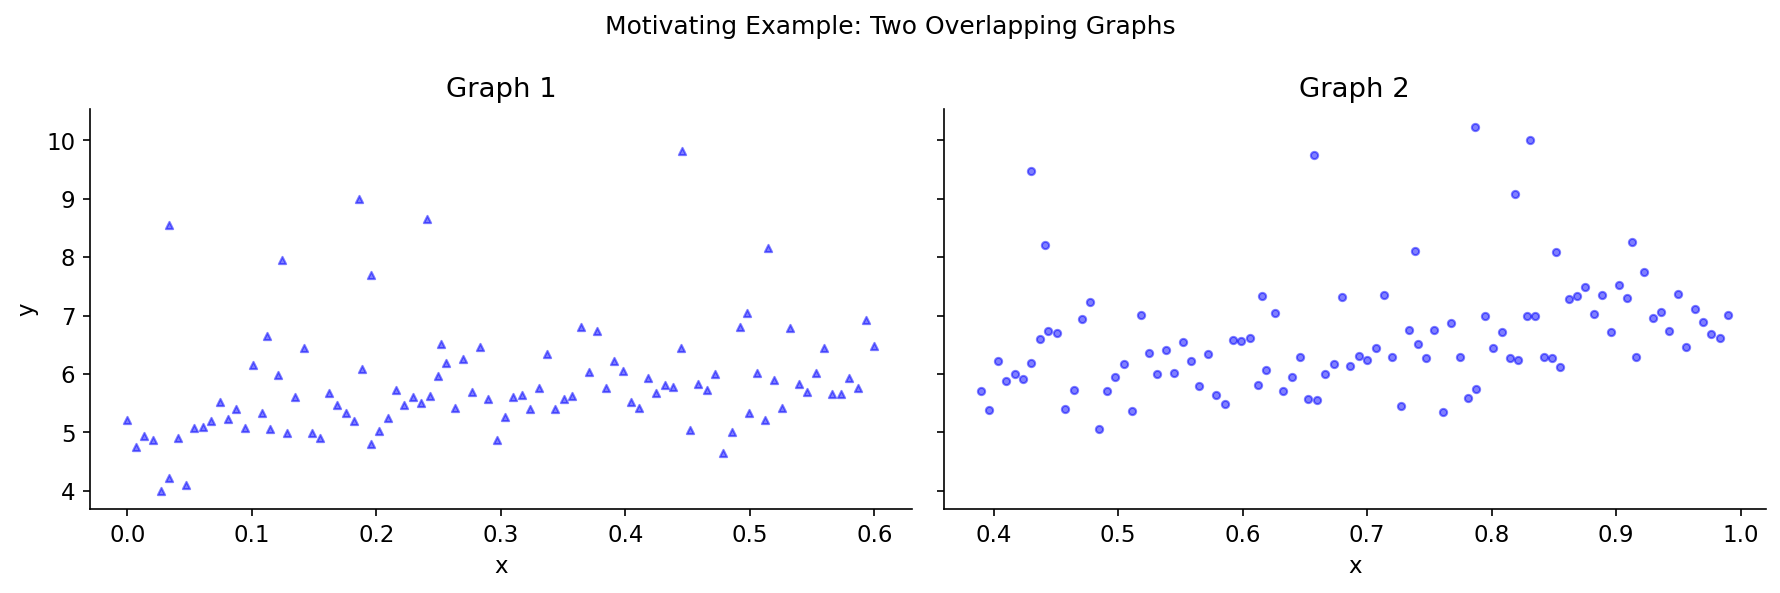

In [19]:
# raw data
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
ax_l.scatter(g1["x"], g1["y"], s=12, alpha=0.5, marker="^", color="blue")
ax_l.set_title("Graph 1")
ax_l.set_xlabel("x")
ax_l.set_ylabel("y")
ax_r.scatter(g2["x"], g2["y"], s=12, alpha=0.5, color="blue")
ax_r.set_title("Graph 2")
ax_r.set_xlabel("x")
fig.suptitle("Motivating Example: Two Overlapping Graphs", fontsize=12)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/example_data.png", dpi=150)
plt.show()

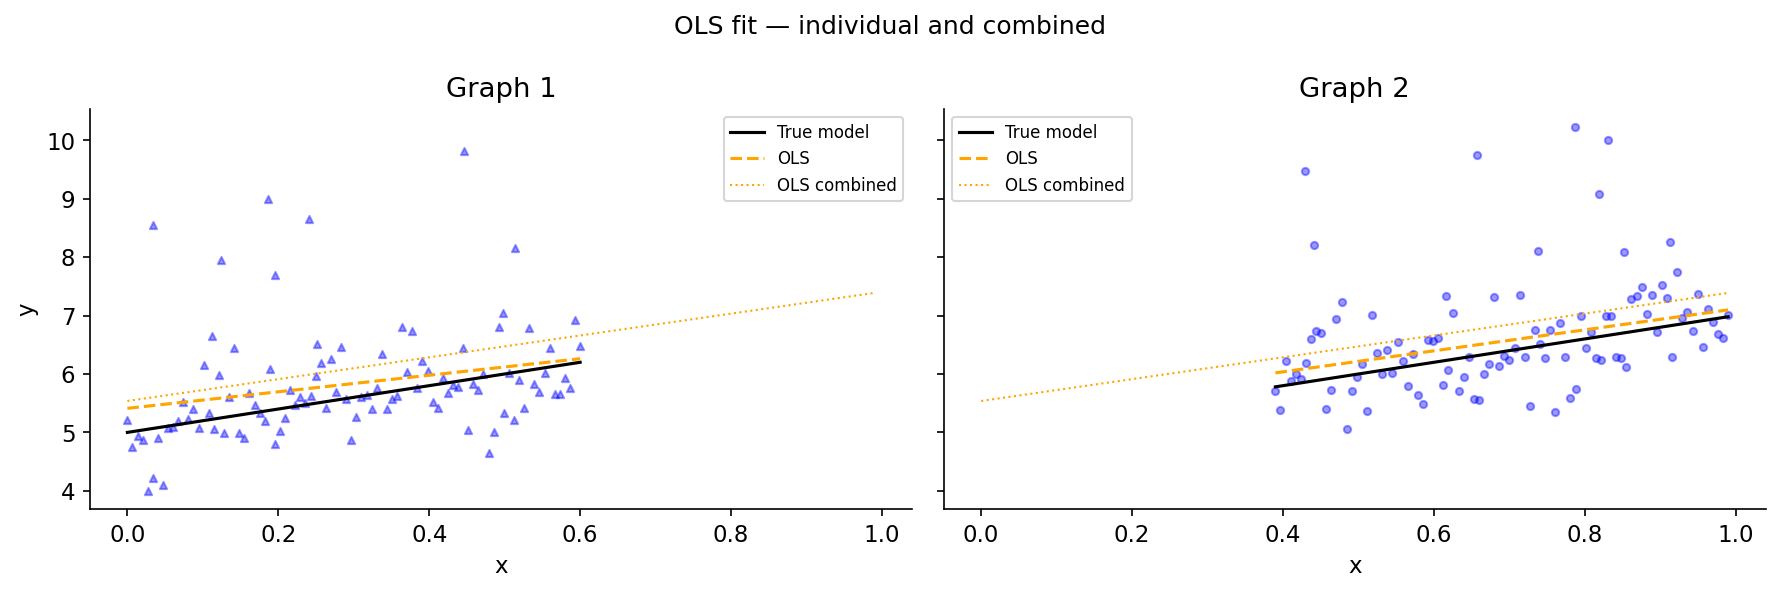

In [20]:
# OLS
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for i, (ax, g, x_plot, ols_p, label, color) in enumerate([
    (ax_l, g1, x1_plot, ols1_params, "Graph 1", "blue"),
    (ax_r, g2, x2_plot, ols2_params, "Graph 2", "blue")]):
    if i == 0:
        m = "^"
    else:
        m = "o"
    ax.scatter(g["x"], g["y"], s=12, alpha=0.4, marker=m, color=color)
    ax.plot(x_plot, eval_line(x_plot, true_params),
            color="black", linewidth=1.5, label="True model")
    ax.plot(x_plot, eval_line(x_plot, ols_p),
            color="orange", linestyle="--", linewidth=1.5, label="OLS")
    ax.plot(x_all, eval_line(x_all, ols_comb_params),
            color="orange", linestyle=":", linewidth=1, label="OLS combined")
    ax.set_title(label)
    ax.set_xlabel("x")
    ax.legend(fontsize=8)
ax_l.set_ylabel("y")
fig.suptitle("OLS fit — individual and combined", fontsize=12)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/example_ols.png", dpi=150)
plt.show()

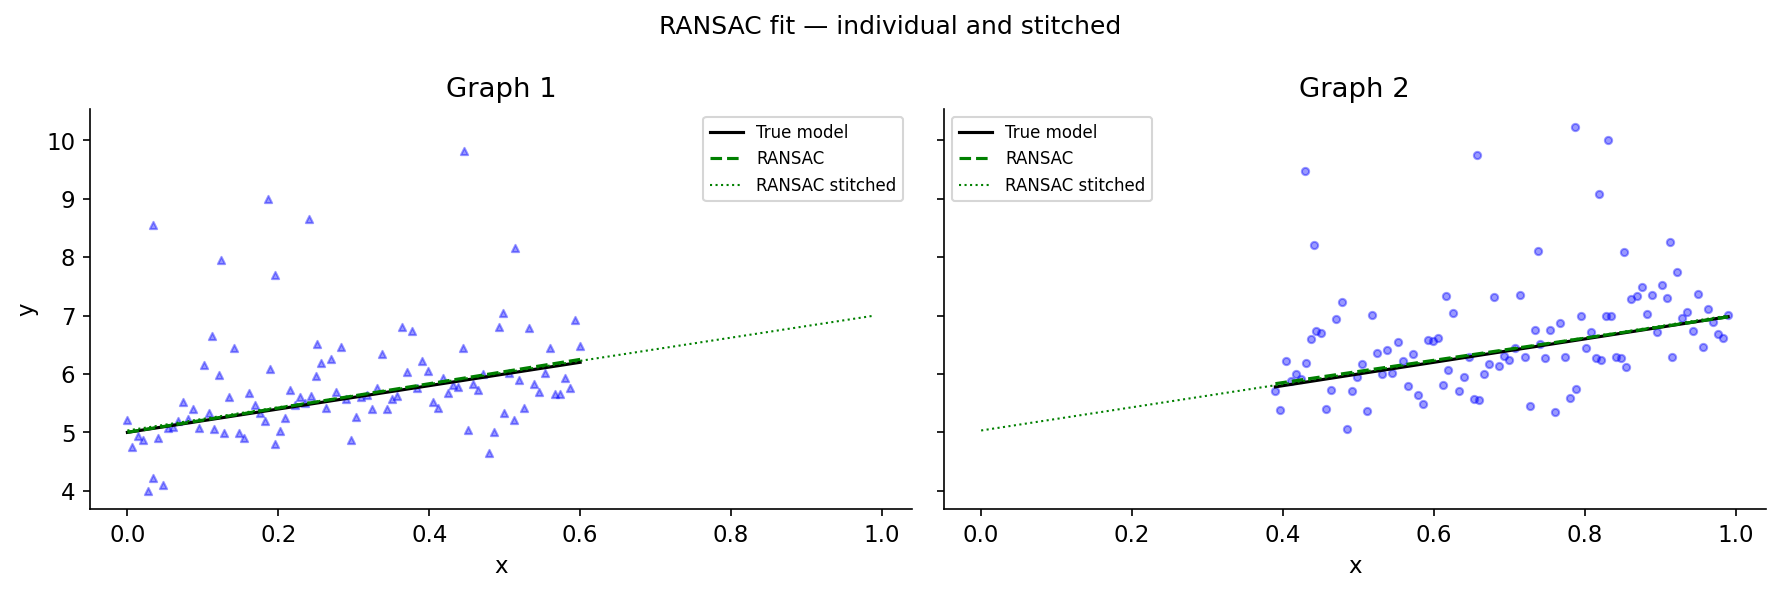

In [21]:
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for i, (ax, g, x_plot, ransac_p, label, color) in enumerate([
    (ax_l, g1, x1_plot, ransac1_params, "Graph 1", "blue"),
    (ax_r, g2, x2_plot, ransac2_params, "Graph 2", "blue")]):
    if i == 0:
        m = "^"
    else:
        m = "o"
    ax.scatter(g["x"], g["y"], s=12, alpha=0.4, marker=m, color=color)
    ax.plot(x_plot, eval_line(x_plot, true_params),
            color="black", linewidth=1.5, label="True model")
    ax.plot(x_plot, eval_line(x_plot, ransac_p),
            color="green", linestyle="--", linewidth=1.5, label="RANSAC")
    ax.plot(x_all, eval_line(x_all, stitch_params),
            color="green", linestyle=":", linewidth=1, label="RANSAC stitched")
    ax.set_title(label)
    ax.set_xlabel("x")
    ax.legend(fontsize=8)
ax_l.set_ylabel("y")
fig.suptitle("RANSAC fit — individual and stitched", fontsize=12)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/example_ransac.png", dpi=150)
plt.show()

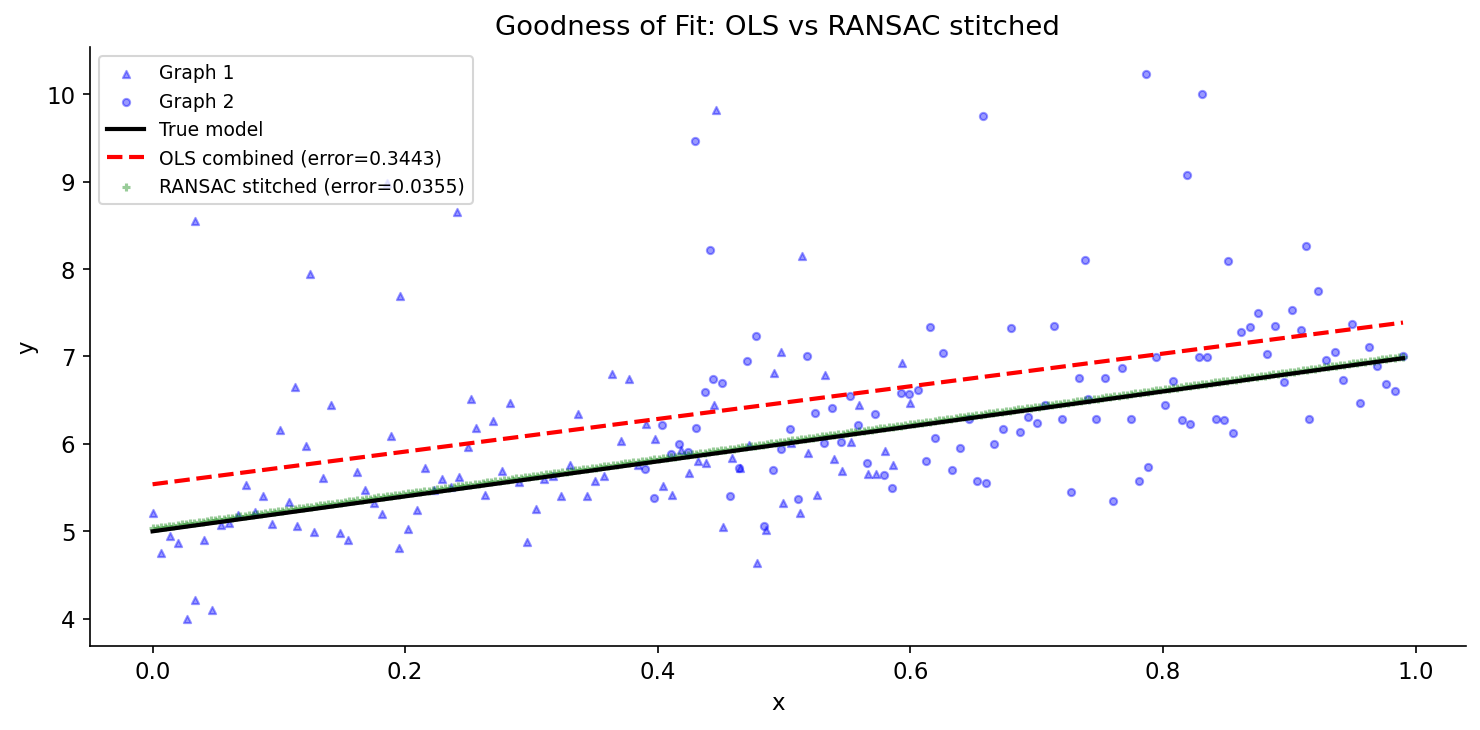

In [22]:
# OLS and RANSAC comparison

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(g1["x"], g1["y"], s=12, alpha=0.4, color="blue", marker="^", label="Graph 1")
ax.scatter(g2["x"], g2["y"], s=12, alpha=0.4, color="blue", label="Graph 2")

ax.plot(x_all, eval_line(x_all, true_params),
        color="black", linewidth=2, label="True model")
ax.plot(x_all, eval_line(x_all, ols_comb_params),
        color="red", linestyle="--", linewidth=2,
        label=f"OLS combined (error={0.3443:.4f})")
ax.scatter(x_all, eval_line(x_all, stitch_params),
         s=12, alpha=0.4, color="green", marker="+",
        label=f"RANSAC stitched (error={0.0355:.4f})")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Goodness of Fit: OLS vs RANSAC stitched")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/example_combined.png", dpi=150)
plt.show()

---
## Experiment 7 — Does RANSAC improve with N? <a id="experiment-7"></a>

Fix $\varepsilon = 0.30$. Vary $n$ from 2 to 8132 doubling every step. Repeat 100 times.


In [23]:
df7 = pd.read_csv('results/exp7.csv').rename(columns=COL_NAMES)
df7.head()

,Run Index,Total Points (N),Outlier Fraction (ε),Expected Inliers (d),Model Parameters (m),Iterations Used (k),Inlier Threshold (t),Repeat Number,Wall-Clock Time (μs),Model Error (Euclidean)
0,0,4,0.3,2,2,70,1.0,0,2.0,0.337224
1,1,4,0.3,2,2,70,1.0,1,2.0,5.411984
2,2,4,0.3,2,2,70,1.0,2,1.0,7.936878
3,3,4,0.3,2,2,70,1.0,3,1.0,13.717579
4,4,4,0.3,2,2,70,1.0,4,1.0,3.128811


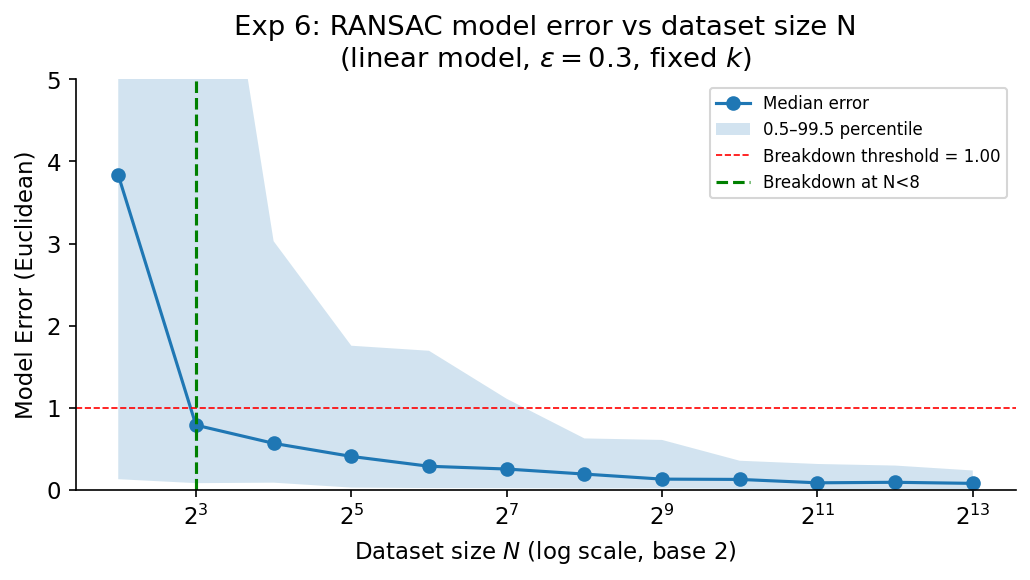

Breakdown at N < 8


In [24]:
BREAKDOWN_THRESHOLD = 2 * 0.5  # 2 * NOISE_STD

fig, ax = plt.subplots(figsize=(7, 4))

grp = df7.groupby("Total Points (N)")["Model Error (Euclidean)"]
means  = grp.median()
lower  = grp.quantile(0.005)
upper  = grp.quantile(0.995)

breakdown_rows = means[means > BREAKDOWN_THRESHOLD]
breakdown_n    = 2**(breakdown_rows.index[0] - 1) if not breakdown_rows.empty else 0

ax.plot(means.index, means.values, marker='o', label="Median error")
ax.fill_between(means.index, lower, upper, alpha=0.2, label="0.5–99.5 percentile")
ax.axhline(BREAKDOWN_THRESHOLD, color="red", linestyle="--",
           linewidth=0.8, label=f"Breakdown threshold = {BREAKDOWN_THRESHOLD:.2f}")

ax.axvline(x=breakdown_n, color="green", linestyle="--",
           label=f"Breakdown at N<{breakdown_n}")

ax.set_xscale('log', base=2)
ax.set_xlabel("Dataset size $N$ (log scale, base 2)")
ax.set_ylabel("Model Error (Euclidean)")
ax.set_ylim(0, 5)
ax.set_title("Exp 6: RANSAC model error vs dataset size N\n"
             "(linear model, $\\varepsilon=0.3$, fixed $k$)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/exp7.png", dpi=150)
plt.show()

if breakdown_n is not None:
    print(f"Breakdown at N < {breakdown_n}")
else:
    print("No breakdown detected within range")